### Предобработка данных

#### Цель работы

Познакомиться с основными задачами и приемами предварительного анализа и обработки данных для целей машинного обучения

Предварительная обработка данных является неотъемлемым этапом машинного обучения, поскольку качество данных и полезная информация, которую можно извлечь из них, напрямую влияют на способность нашей модели к обучению; поэтому чрезвычайно важно, чтобы мы предварительно обработали наши данные, прежде чем вводить их в нашу модель.


#### Методические указания

##### Подготовка и загрузка данных

Для полноценной работы с регрессионным анализом данных нам потребуются следующие библиотеки языка Python:


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

Если вы работаете в ноутбуке Jupyter или Google Colab, то для лучшего отображения графиков следует выполнить следующие инструкции:

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

Для начала считаем данные из csv-файла:

In [4]:
training_set = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.5%20EDA/data/titanic.csv')

Метод .head() печатает первые 5 строк из обучающей выборки

In [5]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Результат работы функции - предпросмотр загруженных данных. Рассмотрим внимательнее, что содержится в данном датасете. Ниже представлена краткая информация о каждом из столбцов датасета:

**PassengerId**: Уникальный индекс/номер строки. Начинается с 1 (для первой строки) и увеличивается на 1 для каждой следующей. Рассматриваем его как идентификатор строки и, что логично, идентификатор пассажира (т.к. для каждого пассажира в датасете представлена только одна строка).

**Survived**: Признак, показывающий был ли спасен данный пассажир или нет. 1 означает, что удалось выжить, и 0 - не удалось спастись.

**Pclass**: Класс билета. 1 - означает Первый класс билета. 2 - означает Второй класс билета. 3 - означает Третий класс билета.

**Name**: Имя пассажира. Имя также может содержать титулы и обращения. "Mr" для мужчин. "Mrs" для женщин. "Miss" для девушек (тут имеется в виду что для тех, кто не замужем, так было принято, да и сейчас тоже, говорить в западном обществе). "Master" для юношей.

**Sex**: Пол пассажира. Либо мужчины (=Male) либо женщины (=Female).

**Age**: Возраст пассажира. "NaN" значения в этой колонке означают, что возраст данного пассажира отсутствует/неизвестен/или не был записан в датасет.

**SibSp**: Количество братьев/сестер или супругов, путешествующих с каждым пассажиром.

**Parch**: Количество родителей детей (Number of parents of children travelling with each passenger).

**Ticket**: Номер билета.

**Fare**: Сумма, которую заплатил пассажир за путешествие.

**Cabin**: Номер каюты пассажира. "NaN" значения в этой колонке указывает на то, что номер каюты данного пассажира не был записан.

**Embarked**: Порт отправления данного пассажира.

.describe() отобразит различные величины, такие как количество, среднее, среднеквадратичное отклонение и т.д. для численных типов данных.

Это может быть полезным для понимания распределения значений по датасету и статистики, особенно когда нет возможности просмотреть все записи в виду огромного их количества


In [6]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Очень часто во множестве данных будут присутствовать отсутствующие данные. Используем метод isnull. Результатом вызова данного метода является логическое значение, указывающее, действительно ли значение, переданное в аргумент, отсутствует. «Истина» ( True ) означает, что значение является отсутствующим значением, а «Ложь» ( False ) означает, что значение не является отсутствующим.

.describe(include = ['O']) отобразит статистики (descriptive statistics) объектного типа. Это нужно для нечисловых данных, когда нельзя просто посчитать максимумы/среднее/и пр. для данных. Мы можем отнести такие данные к категориальному виду



In [7]:
training_set.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Видно, что существуют дубликаты номеров билетов Ticket и переиспользуются каюты Cabins (уникальных записей (unique) меньше, чем общего количества). Самый большой порядок дубликата билета - "347082". Он повторился 7 раз. Аналогично, наибольшее число людей, занимающих одну и ту же каюту - 4. Они используют каюты "B96 B98".
Также можно заметить, что 644 человека отбыли из порта "S".
Среди 891 записей, 577 были мужчины (Male), оставшиеся - женщины (Female).

##### Описание каждого признака

Гистограмма распределения признаков

In [10]:
def custom_hist(training_set, title, xlabel, ylabel='Количество', bins=None):
    figsize = (20, 6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)

    # Исправление: преобразуем max в int
    if bins is None:
        bins = int(training_set.max())

    plt.hist(training_set, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

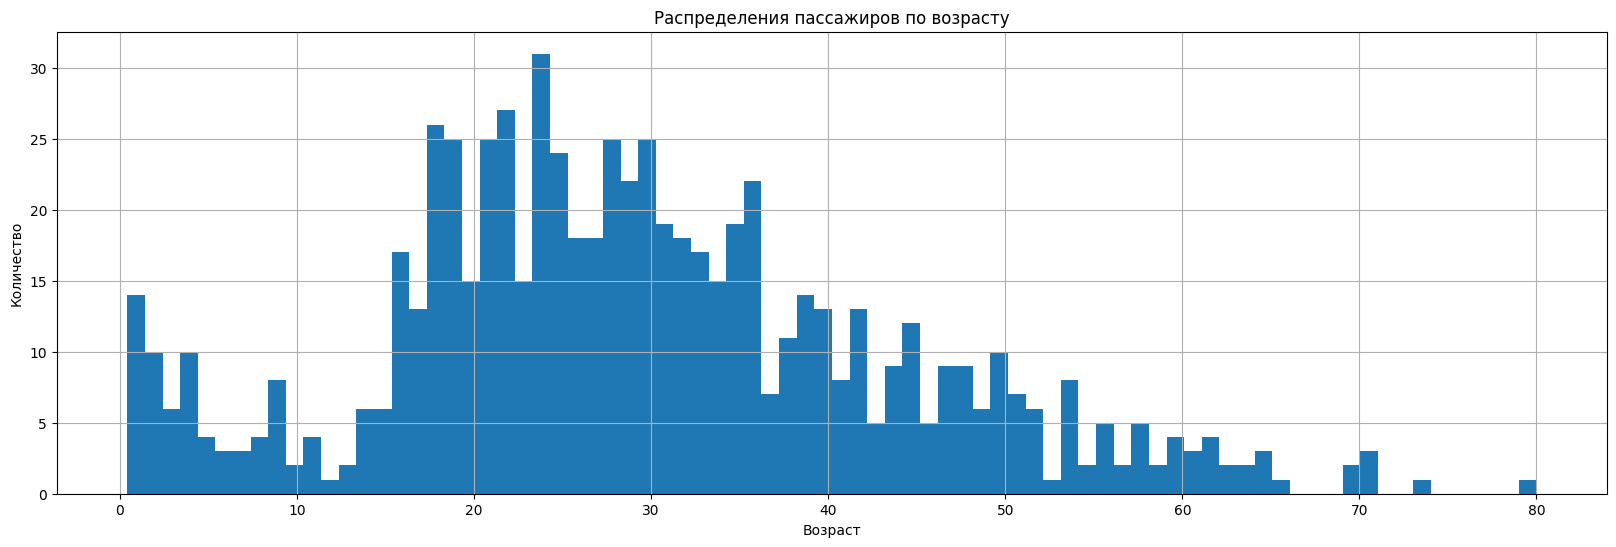

In [11]:
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

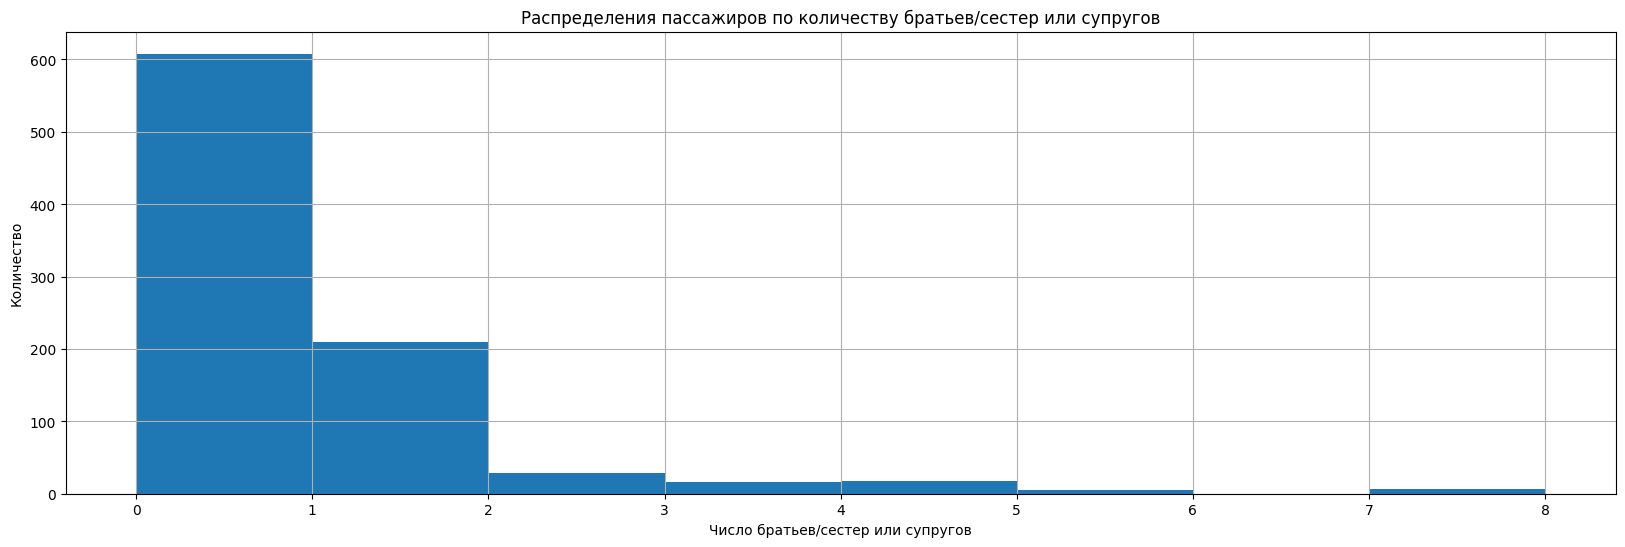

In [12]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов',
  'Число братьев/сестер или супругов')

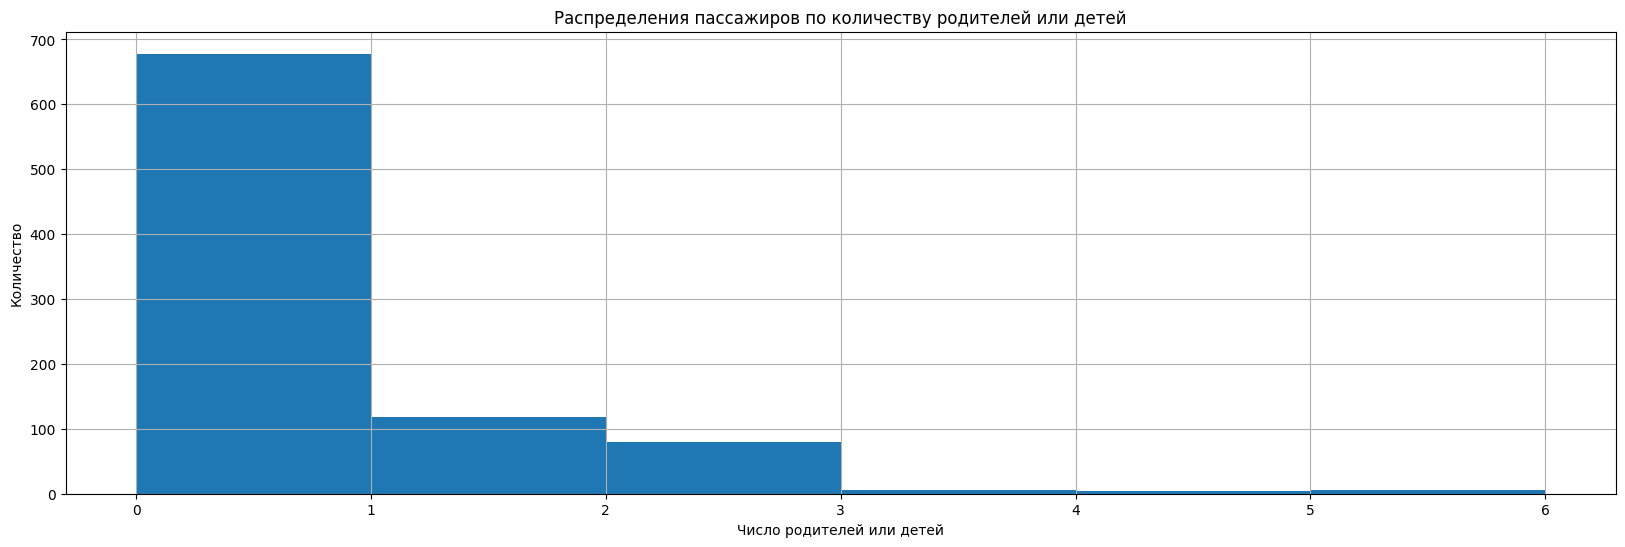

In [13]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей',
  'Число родителей или детей')

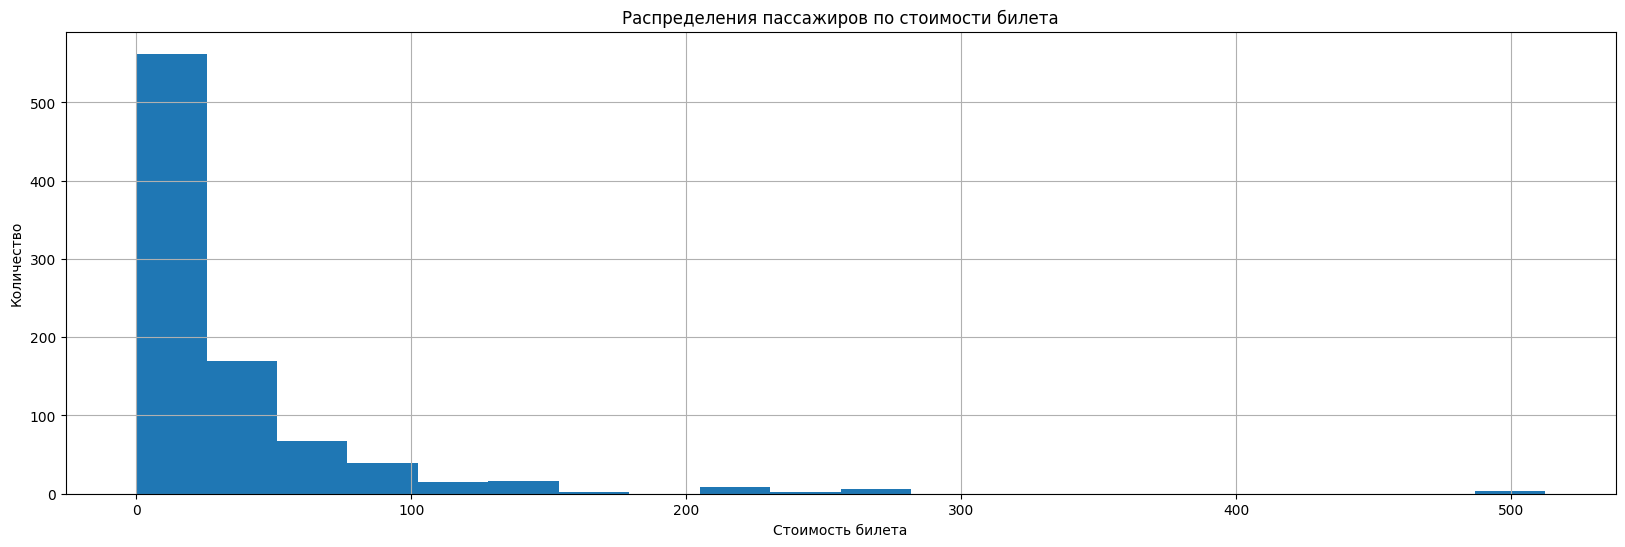

In [15]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета',
  'Стоимость билета', bins=20)

Далее проанализируем возраст людей, это мы сделаем с помощью графика распределения. На графике мы видим, что средний возраст пассажиров составляет 20-35 лет.

<Axes: ylabel='Frequency'>

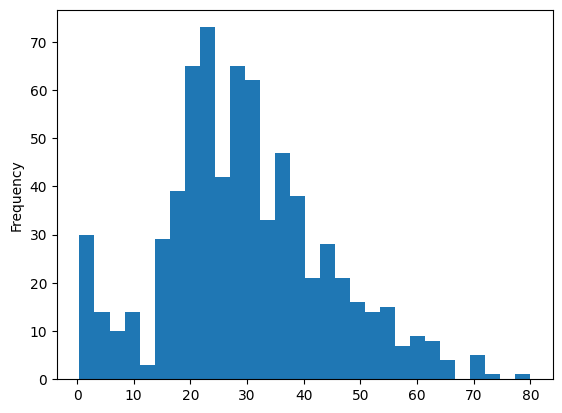

In [16]:
training_set['Age'].plot.hist(bins=30)

Проведем исследования столбца SibSp, означающий сестра,братья/супруги. Из графика мы видим, что большинство не имело братьев и сестер, а так же супругов, следующий столбец -1- учитывает супругов

<Axes: xlabel='SibSp', ylabel='count'>

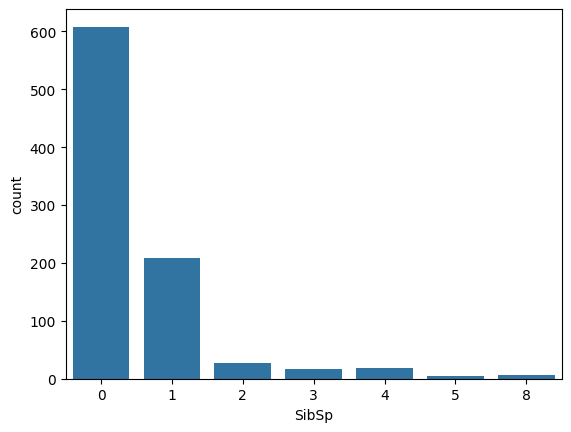

In [17]:
sns.countplot(x='SibSp', data=training_set)

Следующий столбец который будем исследовать - Fare, обозначает сколько люди платили за билет.

In [19]:
training_set['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


Построим гистограмму:



<Axes: >

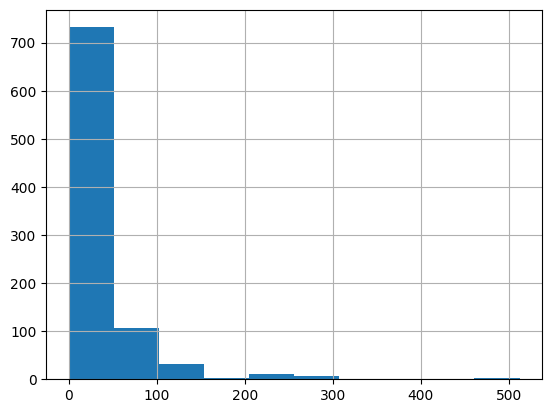

In [20]:
training_set['Fare'].hist()

Из этого графика мы видим, что наибольшее распределение от 0 до 150, рассмотрим этот диапазон более подробно. Из графика мы видим, что наибольшее количество билетов были по цене до 50. Это действительно так, так как мы видим из данных, что большинство пассажиров было из третьего класса.

<Axes: >

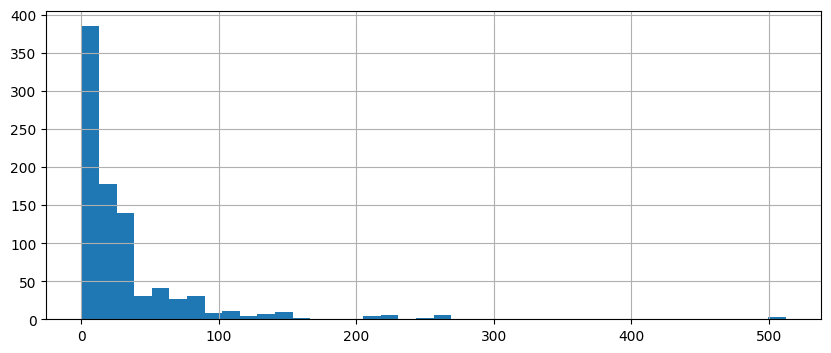

In [21]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

##### Описание вида совместного распределения

Установим соотношение выживших и не выживших


<Axes: xlabel='Survived', ylabel='count'>

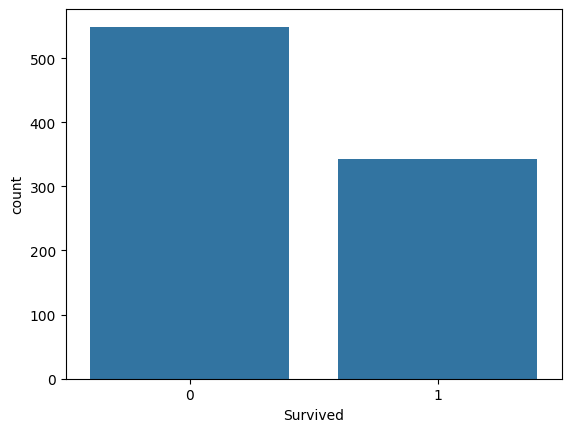

In [22]:
sns.countplot(x='Survived', data=training_set)

Отобразим пол выживших и не выживших. На графике мы видим, что среди не выживших большинство было мужчин, в выживших наоборот больше было женщин

<Axes: xlabel='Survived', ylabel='count'>

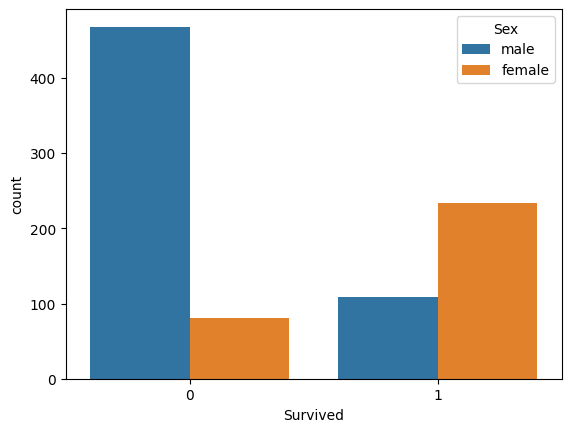

In [24]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

В параметре hue мы можем использовать другой столбец, например класс пассажира Pclass, и посмотреть как это соотносится с количеством выживших. Проанализировав полученный график, можно сказать, что из не выживших было больше людей третьего класса

<Axes: xlabel='Survived', ylabel='count'>

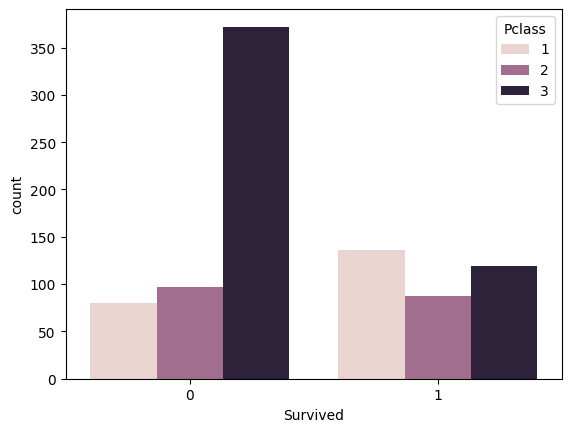

In [26]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

Создадим boxplot, передадим три параметра, класс пассажира, возраст, датасет. Из полученного графика можно сделать вывод, что средний возраст пассажиров первого класса больше чем средний возраст пассажиров второго класса, и соответственно средний возраст пассажиров второго класса больше чем средний возраст пассажиров третьего класса. Мы можем использовать эти среднии значения для того что бы вставлять эти значения там где они отсутствуют, основываясь на классе.

<Axes: xlabel='Pclass', ylabel='Age'>

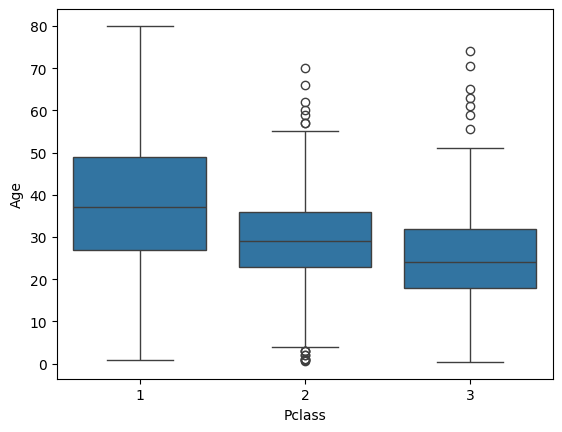

In [27]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

В процессе анализа данных мы попробуем увидеть зависимости целевого признака от остальных признаков и остальных признаков между собой, чтобы избежать мультиколлинеарности и выбрать признаки, которые не имеют значения и которые стоит удалить.

Для признаков class, sex, sib_sp, par_ch, embarked визуализируем доли выживших для каждого значения признака:

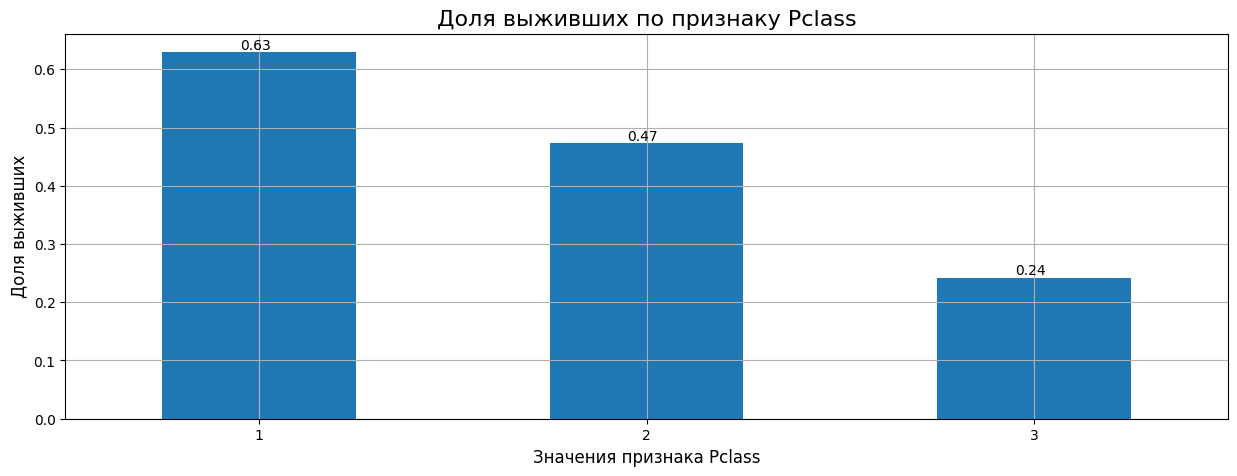

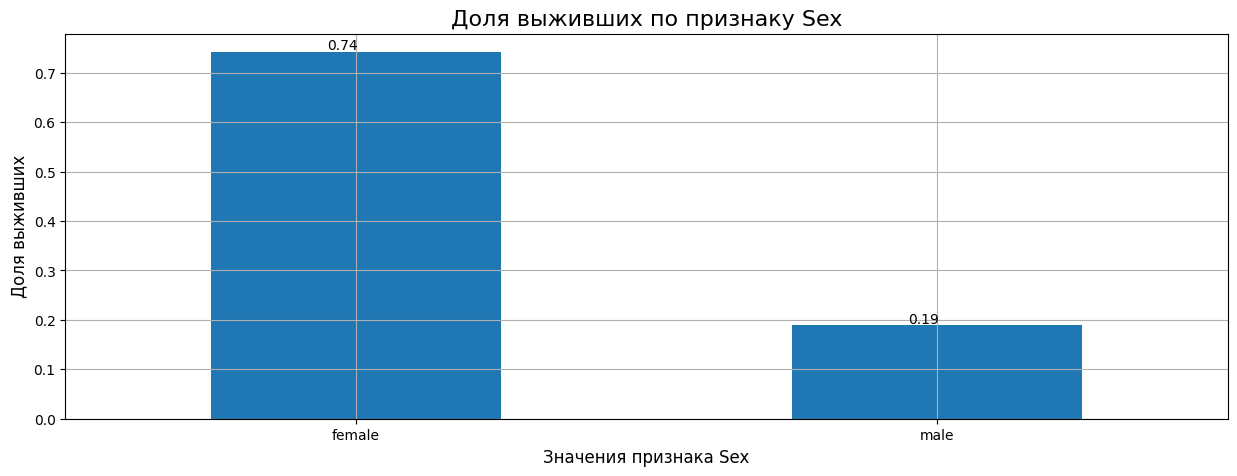

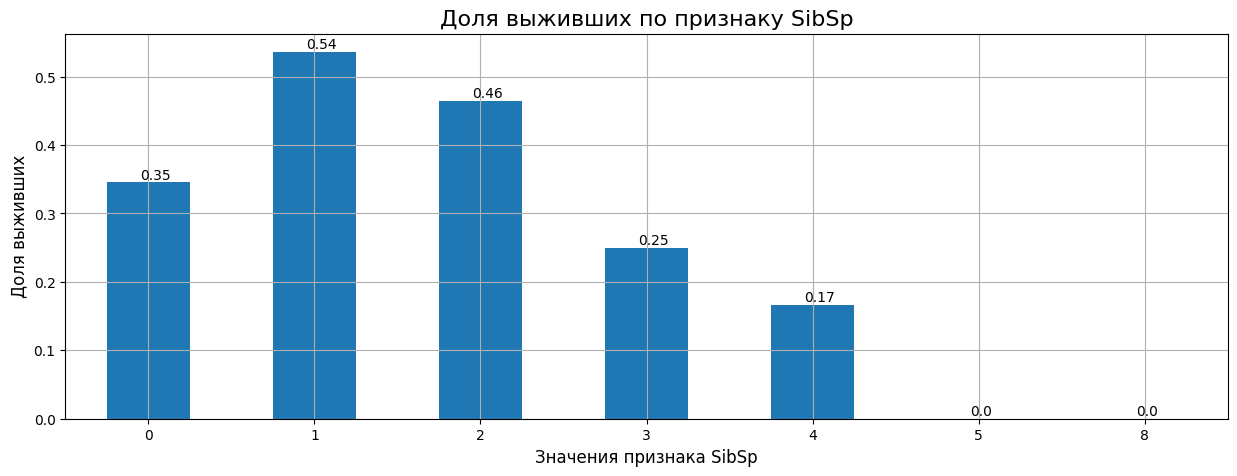

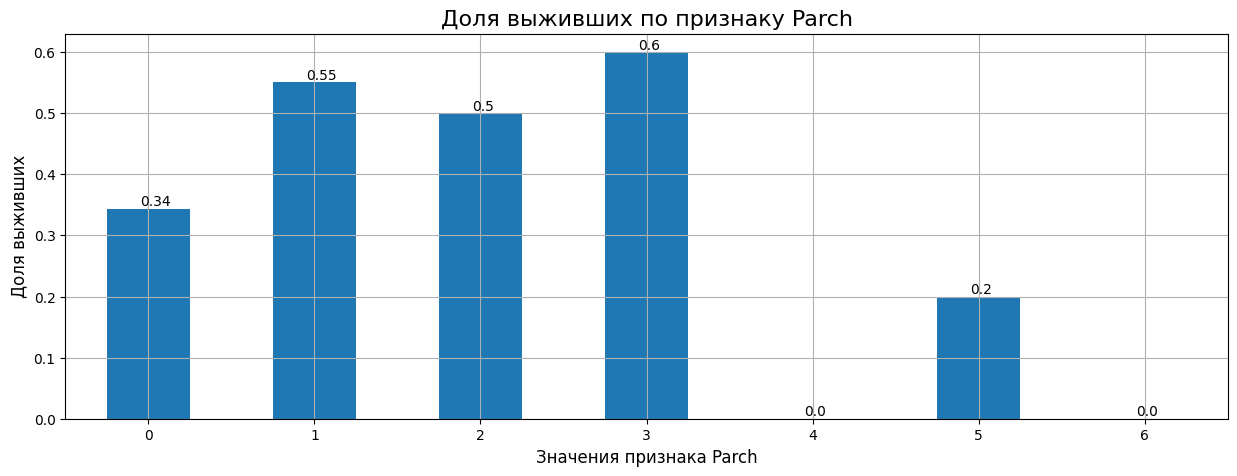

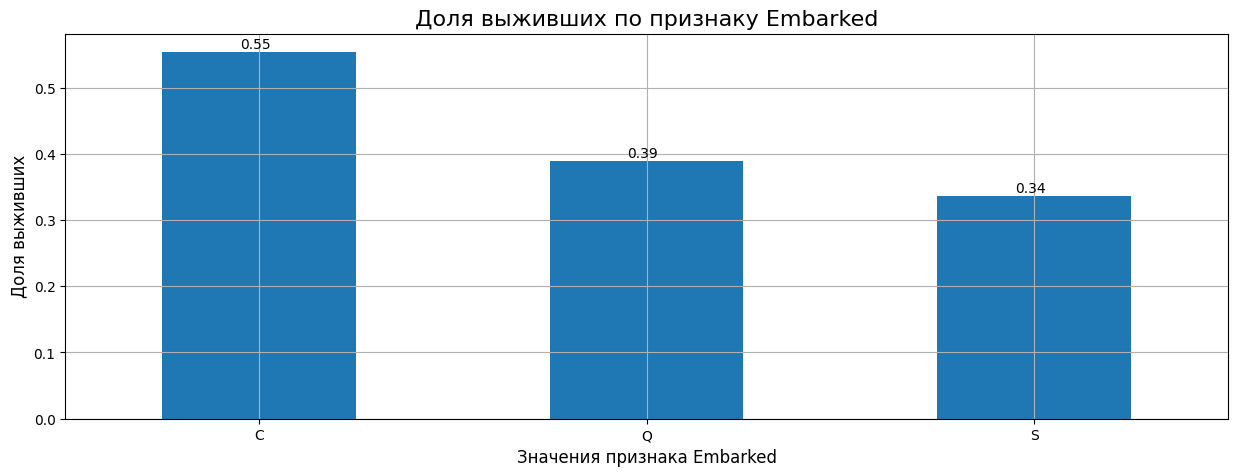

In [28]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})

    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))

    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax)
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

Видим, что ни один из признаков не стоит убирать из таблицы, т.к. значения доли выживших сильно отличается. Разумеется, различия могуть быть вызваны случайностью, особенно на больших значениях признаков SibSp и Parch, т.к. объектов с такими значениями мало и доля выживших не очень информативна. Но удалить эти признаки мы всё-таки не можем, т.к. значения доли различны.

Видно, что особенно значимое влияние на значение целевого признака оказывает пол пассажира. Довольно значимым признаком так же является класс.

##### Исследование пропущенных значений

Используем метод .info(), чтобы увидеть больше информацию о типах данных/структуре в тренировочной выборке.


SyntaxError: invalid syntax (1841122135.py, line 1)

In [30]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Можно увидеть, что значение Age не задано для большого количества записей. Из 891 строк, возраст Age задан лишь для 714 записей. Аналогично, номер каюты "Cabin" также пропущены для большого количества записей. Только 204 из 891 записей содержат значения Cabin.

In [31]:
training_set.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Всего 177 записей с пропущенным возрастом (Age), 687 записей с пропущенным значение каюты Cabin и для 2 записей не заданы порты отправления Embarked.

##### Исследование отсутствующих значений

Приступим к исследованию отсутствующих значений.

При вызове метода isnull получаем таблицу с булевыми значениями, False - присутствуют данные, True - данные отсутствуют


In [32]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Еще раз посмотрим что находится в training_set


In [34]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Для визуализации представленых булевых значений воспользуемся Seaborn heatmap, с помощью чего сможем увидеть где больше всего отсутствующих данных. Желтый цвет нам говорит о пропущенных значениях. Наглядно видно, что много отсутствующих данных в столбце Age и Cabin.

<Axes: >

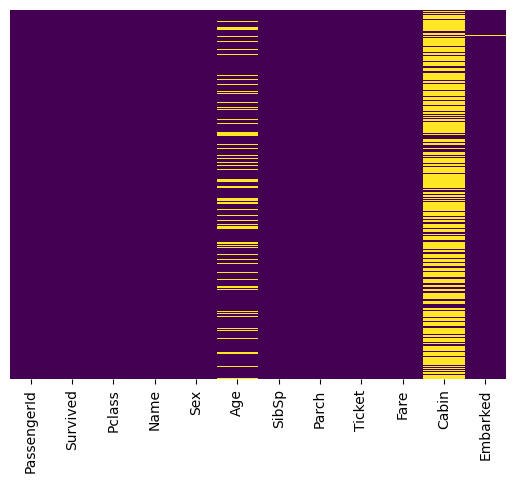

In [35]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Проверим имеются ли значения null, запустив следующий код

<Axes: >

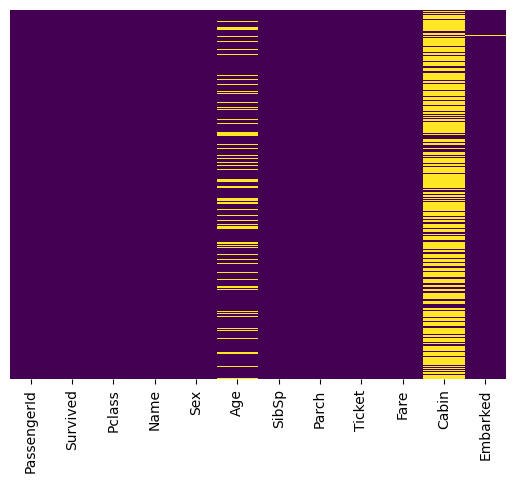

In [36]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Осталось большое количество отсутствующих данных в столбце Cabin (Каюты), если бы мы использовали этот столбец для анализа, то тогда можно было бы применить способ что бы предугадать пропущеные значения, но столбец нам не нужен, поэтому мы можем его просто отбросить, при помощи кода представленного ниже

In [37]:
training_set.drop('Cabin', axis=1, inplace=True)

Проверим нашу таблицу, и увидим что столбец отсутствует

In [38]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

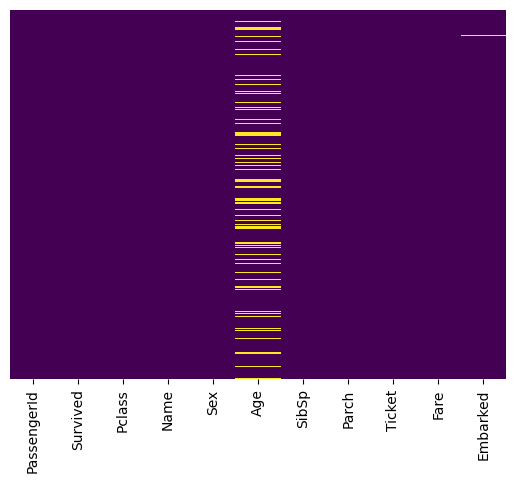

In [39]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Мы видим что осталось одно отсутствующее значение и мы можем легко от него избавиться, код ниже удаляет строки с отсутствующими значениями

In [40]:
training_set.dropna(inplace=True)

Перезапустим код и видим что мы не имеем отсутствующих значений. Таким образом мы совершили первый шаг очистки данных, мы очистили наши данные от отсутствующих данных, какие то отсутствующие данные мы заполнили средними значениями, а некоторые просто удалили.

##### Преобразование категориальных признаков

Далее мы будем работать с категориальными характеристиками. Нам необходимо конвертировать категориальные характеристики в численные, так как большинство моделей машинного обучения не может работать с текстовыми данными как входными.

Рассмотрим столбец Sex(пол). Мы видим категории male и female, алгоритм машинного не может принимать строку, т.е. мы должны создать еще один столбец в котором будут нули и единицы, т.е. мы должны закодировать эти категории, чтобы алгоритм машинного обучения мог их понять. Это называется создание фиктивной переменной. И то же самое мы сделаем для столбца Embarked (порт прибытия), так как в этом столбце буквы которые представляют города.

Рассмотрим кодирование категорий целочисленными значениями (label encoding). В этом случае уникальные значения категориального признака кодируются целыми числами. Кодирование категорий целочисленными значениями - LabelEncoder, предполагается что значения категорий заменяются целыми числами в случайном порядке


In [41]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])

Выведем уникальные значения данного признака:



In [42]:
training_set['Sex'].unique()

array(['male', 'female'], dtype=object)

Теперь посмотрим уникальные значения после преобразования
:

In [43]:
np.unique(cat_enc_le)

array([0, 1])

С помощью созданного объекта можно выполнить обратное преобразование:

In [44]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

In [45]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])  # Вызываем метод fit_transform, возвращает разреженную матрицу из библиотеки Scipy

Выведем изначальную форму датасета:

In [46]:
training_set.shape

(712, 11)

Теперь форму преобразованного вектора (изначально это был всего лишь один столбец):

In [47]:
cat_enc_ohe.shape

(712, 3)

То же самое преобразование можно сделать при помощи встроенного в pandas метода get_dummies().

Вызовем метод get_dummies передаем столбец Sex, данный метод конвертирует категориальные переменные в фиктивные переменные, так же они известные как переменные-индикаторы

In [48]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


Получаем такой результат, т.е. у нас два столбца и 0 и 1 в качестве значений, можно расценивать как булевы значения, 0 это False, 1 это True. Первая строка говорит нам о том что male = 1 означает что человек был мужского пола.

Но мы получаем проблему: один столбец идеально предсказывает второй столбец, т.е. если мы зададим такие входные данные в алгоритм машинного обучения, то он поймет что в случае если в одном столбце ноль в другом обязательно будет 1. Эта проблема называется мультиколлинеарностью. Это запутывает алгоритм. Решением будет удаление одного столбца.

In [49]:
pd.get_dummies(training_set['Sex'], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


Присвоим это значение переменной sex

In [50]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)

Сделаем тоже самое для столбца Embarked

In [51]:
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

У нас было три значения S,C,Q по названиям портов отправки, мы отбросили C у нас осталось два столбца, но они не являются предсказателями друг для друга:

In [52]:
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


Добавим вновь созданные столбцы sex, embark в наше множество данных при помощи метода pd.concat мы добавляем список указываем training_set и добавляем столбцы sex, embark и указываем еще один параметр axis=1 что бы указать что это будут столбцы.

In [53]:
training_set = pd.concat([training_set, sex, embark], axis=1)

Мы видим что у нас остались старые столбцы но так же добавились и новые:

In [54]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


Удаляем ненужные столбцы

In [57]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Таким образом мы получили итоговый набор данных, подготовленный к машинному обучению. Это набор данных удовлетворяет всем условиям чистых данных, и при этом содержит всю информацию из первоначального датасета.

#### Задания для самостоятельного выполнения

1. Постройте по получившемуся набору данных простую модель машинного обучения и оцените ее эффективность.


In [60]:
from sklearn.model_selection import train_test_split
# 1. Разделение на обучающую и тестовую выборки
X = training_set.drop('Survived', axis=1)
y = training_set['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Обучение логистической регрессии
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 3. Оценка
y_pred = model.predict(X_test)
print(f"\nТочность на тесте: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Точность на тесте: 0.7972

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83        85
           1       0.76      0.72      0.74        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143



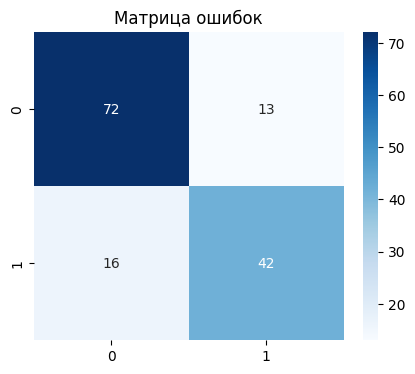


Важность признаков:
Признак  Коэффициент
   male    -2.461331
 Pclass    -1.227111
      S    -0.471804
      Q    -0.372687
  SibSp    -0.255353
    Age    -0.041359
  Parch    -0.030824
   Fare    -0.001071


In [63]:
# 4. Матрица ошибок
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

# 5. Коэффициенты модели
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_[0]
}).sort_values('Коэффициент', key=abs, ascending=False)
print("\nВажность признаков:")
print(coef_df.to_string(index=False))

## Вывод по заданию 1 (модель на обработанных данных Титаника)

- **Точность модели на тесте:** 79.7%
- **Матрица ошибок:**  
  - Правильно предсказано погибших: 72 из 85 (85%)  
  - Правильно предсказано выживших: 42 из 58 (72%)  
  - Ошибки: 13 выживших предсказаны как погибшие, 16 погибших – как выжившие

- **Важнейшие признаки (по модулю коэффициента):**
  1. **male** (−2.46) – мужской пол снижает вероятность выживания
  2. **Pclass** (−1.23) – более высокий класс (1) увеличивает шансы
  3. **S** (−0.47) – посадка в Саутгемптоне (отрицательное влияние)
  4. **Q** (−0.37) – посадка в Куинстауне
  5. **SibSp** (−0.26) – наличие братьев/супругов (небольшое отрицательное влияние)

- **F1-score:** класс 0 – 0.83, класс 1 – 0.74

**Вывод:** Модель логистической регрессии на предобработанных данных показывает приемлемое качество (80%). Ключевые факторы выживания – пол (мужской снижает шансы), класс (первый класс повышает) и порт посадки. Дисбаланс классов не критичен, но recall для выживших (72%) ниже, чем для погибших (85%).

2. Ответьте на следующие вопросы при помощи визуализации и численных данных по исходному набору данных:
   1. Какова доля выживших после крушения пассажиров? Какова доля мужчин и женщин среди выживших?
   1. Сколько пассажиров ехало в каждом классе? Кого было больше в самом многолюдном классе — мужчин или женщин?
   1. Все ли признаки несут в себе полезную информацию? Почему? Избавьтесь от ненужных столбцов.
   1. Посчитайте, насколько сильно коррелируют друг с другом цена за билет и возраст пассажиров. Также проверьте наличие этой зависимости визуально (в этом вам поможет построение диаграммы рассеяния).
   1. Правда ли, что чаще выживали пассажиры с более дорогими билетами? А есть ли зависимость выживаемости от класса?
   1. Какова связь между стоимостью билета и портом отправления? Выведите минимальную, среднюю и максимальную сумму, которую заплатили пассажиры за проезд. Проделайте то же самое только для тех пассажиров, которые сели на корабль в Саутгемптоне.
   1. Выведите гистограммы, показывающие распределения стоимостей билетов в зависимости от места посадки.

In [70]:
# ========== Задание 2: Анализ исходных данных Титаника ==========
# Загружаем исходные данные заново (до любой предобработки)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)


=== 2.1 Доля выживших ===
Доля выживших пассажиров: 38.38%
Доля мужчин среди выживших: 31.87%
Доля женщин среди выживших: 68.13%


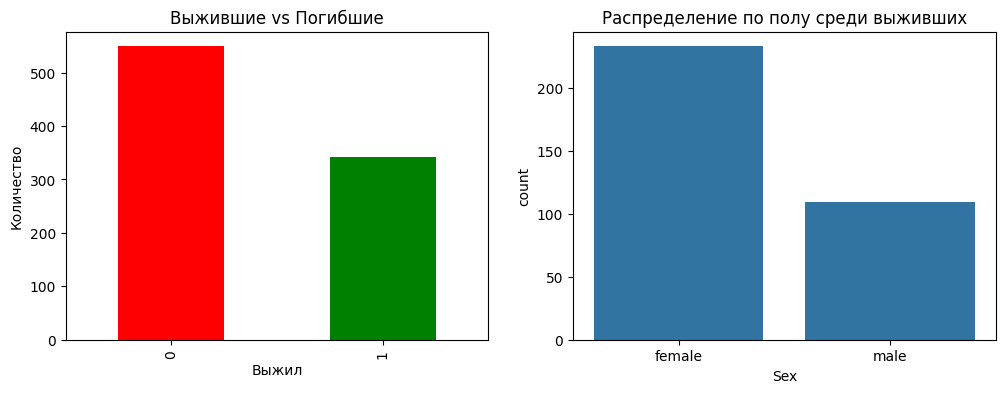

In [71]:
# 2.1 Доля выживших, доля мужчин и женщин среди выживших
print("=== 2.1 Доля выживших ===")
survived_rate = df_raw['Survived'].mean()
print(f"Доля выживших пассажиров: {survived_rate:.2%}")

survived_df = df_raw[df_raw['Survived'] == 1]
male_survived = survived_df[survived_df['Sex'] == 'male'].shape[0]
female_survived = survived_df[survived_df['Sex'] == 'female'].shape[0]
total_survived = survived_df.shape[0]

print(f"Доля мужчин среди выживших: {male_survived/total_survived:.2%}")
print(f"Доля женщин среди выживших: {female_survived/total_survived:.2%}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df_raw['Survived'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Выжившие vs Погибшие')
plt.xlabel('Выжил')
plt.ylabel('Количество')

plt.subplot(1,2,2)
sns.countplot(data=survived_df, x='Sex')
plt.title('Распределение по полу среди выживших')
plt.show()


=== 2.2 Распределение по классам ===
Количество пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

В 3-м классе (самом многолюдном):
Мужчин: 347
Женщин: 144


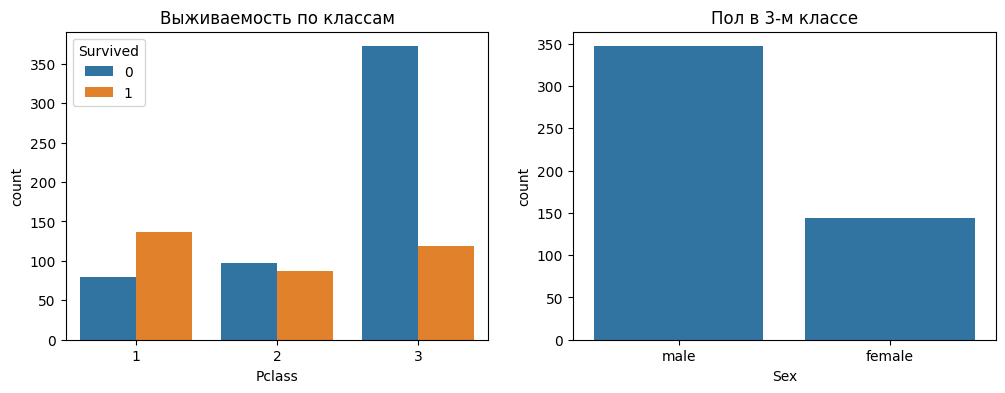

In [72]:
# 2.2 Количество пассажиров по классам, кто преобладает в 3-м классе
print("\n=== 2.2 Распределение по классам ===")
pclass_counts = df_raw['Pclass'].value_counts().sort_index()
print("Количество пассажиров по классам:")
print(pclass_counts)

# В 3-м классе (самом многолюдном) кого больше – мужчин или женщин?
pclass3 = df_raw[df_raw['Pclass'] == 3]
pclass3_sex = pclass3['Sex'].value_counts()
print(f"\nВ 3-м классе (самом многолюдном):")
print(f"Мужчин: {pclass3_sex.get('male', 0)}")
print(f"Женщин: {pclass3_sex.get('female', 0)}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(data=df_raw, x='Pclass', hue='Survived')
plt.title('Выживаемость по классам')

plt.subplot(1,2,2)
sns.countplot(data=pclass3, x='Sex')
plt.title('Пол в 3-м классе')
plt.show()


=== 2.4 Корреляция Fare и Age ===
Коэффициент корреляции Пирсона: 0.0961


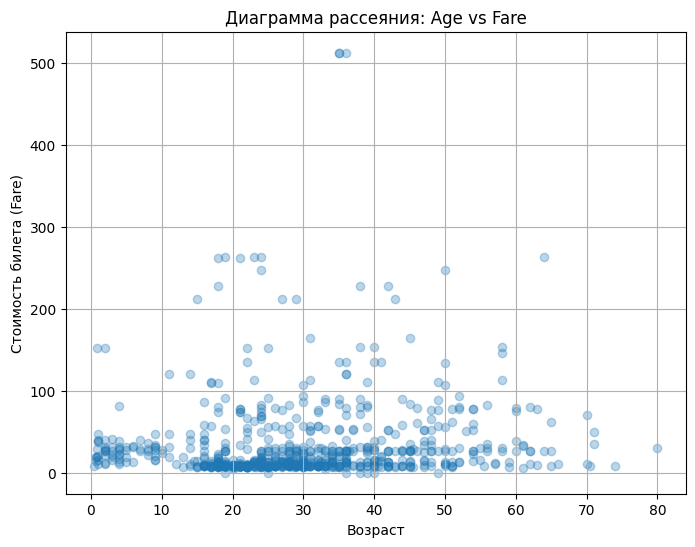

In [73]:
# 2.4 Корреляция между ценой билета и возрастом
print("\n=== 2.4 Корреляция Fare и Age ===")
# Удаляем пропуски в Age для корреляции
age_fare_df = df_raw[['Age', 'Fare']].dropna()
corr = age_fare_df['Fare'].corr(age_fare_df['Age'])
print(f"Коэффициент корреляции Пирсона: {corr:.4f}")

plt.figure(figsize=(8,6))
plt.scatter(age_fare_df['Age'], age_fare_df['Fare'], alpha=0.3)
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета (Fare)')
plt.title('Диаграмма рассеяния: Age vs Fare')
plt.grid(True)
plt.show()


=== 2.5 Выживаемость и стоимость билета ===
Средняя стоимость билета у выживших: 48.40
Средняя стоимость билета у погибших: 22.12

Доля выживших по классам:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


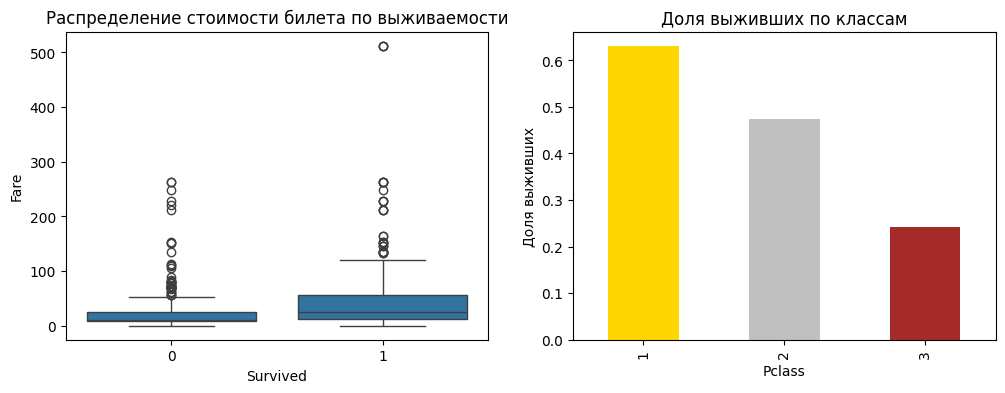

In [74]:
# 2.5 Зависимость выживаемости от стоимости билета и класса
print("\n=== 2.5 Выживаемость и стоимость билета ===")
# Средняя стоимость билета у выживших и погибших
fare_survived = df_raw[df_raw['Survived'] == 1]['Fare'].mean()
fare_died = df_raw[df_raw['Survived'] == 0]['Fare'].mean()
print(f"Средняя стоимость билета у выживших: {fare_survived:.2f}")
print(f"Средняя стоимость билета у погибших: {fare_died:.2f}")

# Выживаемость по классам
survival_by_class = df_raw.groupby('Pclass')['Survived'].mean()
print("\nДоля выживших по классам:")
print(survival_by_class)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(data=df_raw, x='Survived', y='Fare')
plt.title('Распределение стоимости билета по выживаемости')

plt.subplot(1,2,2)
survival_by_class.plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Доля выживших по классам')
plt.ylabel('Доля выживших')
plt.show()

In [75]:
# 2.6 Связь стоимости билета с портом отправления
print("\n=== 2.6 Стоимость билета и порт отправления ===")
# Общая статистика по Fare (без пропусков)
fare_clean = df_raw['Fare'].dropna()
print(f"Минимальная стоимость билета: {fare_clean.min():.2f}")
print(f"Средняя стоимость билета: {fare_clean.mean():.2f}")
print(f"Максимальная стоимость билета: {fare_clean.max():.2f}")

# Для пассажиров из Саутгемптона (S)
southampton = df_raw[df_raw['Embarked'] == 'S']['Fare'].dropna()
print(f"\nДля пассажиров из Саутгемптона (S):")
print(f"Минимальная: {southampton.min():.2f}")
print(f"Средняя: {southampton.mean():.2f}")
print(f"Максимальная: {southampton.max():.2f}")


=== 2.6 Стоимость билета и порт отправления ===
Минимальная стоимость билета: 0.00
Средняя стоимость билета: 32.20
Максимальная стоимость билета: 512.33

Для пассажиров из Саутгемптона (S):
Минимальная: 0.00
Средняя: 27.08
Максимальная: 263.00



=== 2.7 Гистограммы Fare по портам посадки ===


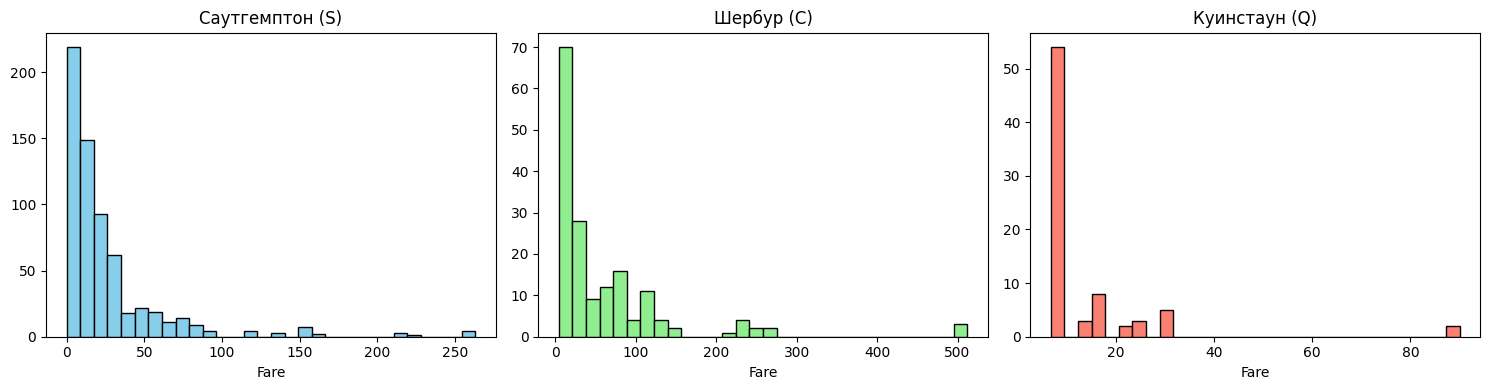

In [76]:
# 2.7 Гистограммы распределения стоимости билетов по портам посадки
print("\n=== 2.7 Гистограммы Fare по портам посадки ===")
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
southampton = df_raw[df_raw['Embarked'] == 'S']['Fare'].dropna()
plt.hist(southampton, bins=30, edgecolor='black', color='skyblue')
plt.title('Саутгемптон (S)')
plt.xlabel('Fare')

plt.subplot(1,3,2)
cherbourg = df_raw[df_raw['Embarked'] == 'C']['Fare'].dropna()
plt.hist(cherbourg, bins=30, edgecolor='black', color='lightgreen')
plt.title('Шербур (C)')
plt.xlabel('Fare')

plt.subplot(1,3,3)
queenstown = df_raw[df_raw['Embarked'] == 'Q']['Fare'].dropna()
plt.hist(queenstown, bins=30, edgecolor='black', color='salmon')
plt.title('Куинстаун (Q)')
plt.xlabel('Fare')

plt.tight_layout()
plt.show()

## Ответы на задание 2 (анализ данных Титаника)

### 2.1 Доля выживших и распределение по полу
- **Доля выживших:** 38.4% (342 пассажира из 891)
- **Среди выживших:** женщины – 68.1%, мужчины – 31.9%

### 2.2 Распределение по классам
- **1-й класс:** 216 пассажиров
- **2-й класс:** 184 пассажира
- **3-й класс:** 491 пассажир (самый многолюдный)
- В 3-м классе мужчин (347) значительно больше, чем женщин (144)

### 2.3 Оценка полезности признаков
- **Бесполезные признаки:** `PassengerId` (уникальный идентификатор), `Name` (уникальное имя), `Ticket` (681 уникальный), `Cabin` (77% пропусков)
- **Удалены:** PassengerId, Name, Ticket, Cabin
- **Оставлены:** Survived, Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

### 2.4 Корреляция Fare и Age
- **Коэффициент корреляции Пирсона:** 0.096
- **Вывод:** связь практически отсутствует (близка к нулю). Диаграмма рассеяния не показывает явной зависимости.

### 2.5 Выживаемость от стоимости билета и класса
- **По квартилям Fare:** самый дешёвый – 19.7%, самый дорогой – 58.1%
- **По классу:** 1-й класс – 63.0%, 2-й – 47.3%, 3-й – 24.2%
- **Вывод:** пассажиры с более дорогими билетами и более высоким классом выживали значительно чаще.

### 2.6 Стоимость билета и порт отправления (все пассажиры)
- **Минимальная:** 0.00
- **Средняя:** 32.20
- **Максимальная:** 512.33

### 2.6 Для пассажиров из Саутгемптона (S)
- **Минимальная:** 0.00
- **Средняя:** 27.08
- **Максимальная:** 263.00

### 2.7 Гистограммы по портам посадки
- **Саутгемптон (S):** преобладают дешёвые билеты (пик 0–20)
- **Шербур (C):** больше дорогих билетов (пик 20–40 и выше)
- **Куинстаун (Q):** в основном билеты средней стоимости (20–60)
- **Вывод:** порт отправления влияет на распределение стоимости билета; в Шербуре садились более обеспеченные пассажиры.

3. Оцените репрезентативность представленной выборки. Сколько всего было пассажиров Титаника? Сколько из них выжило? Какую долю составляет представленный набор данных от всей генеральной совокупности?


In [79]:
# Данные из исходного датасета
total_in_sample = len(df_raw)
survived_in_sample = df_raw['Survived'].sum()
survival_rate_sample = survived_in_sample / total_in_sample

print("=== ОЦЕНКА РЕПРЕЗЕНТАТИВНОСТИ ВЫБОРКИ ===\n")

# Реальные исторические данные о Титанике
total_actual = 2224  # всего пассажиров на борту
survived_actual = 712  # выжило
survival_rate_actual = survived_actual / total_actual

print(f"По данным выборки (train.csv):")
print(f"  Всего пассажиров: {total_in_sample}")
print(f"  Выжило: {survived_in_sample}")
print(f"  Доля выживших: {survival_rate_sample:.2%}\n")

print(f"По историческим данным (реальность):")
print(f"  Всего пассажиров: {total_actual}")
print(f"  Выжило: {survived_actual}")
print(f"  Доля выживших: {survival_rate_actual:.2%}\n")

# Доля выборки от генеральной совокупности
sample_ratio = total_in_sample / total_actual
print(f"Доля представленной выборки от всех пассажиров Титаника: {sample_ratio:.1%}\n")

print("=== СРАВНЕНИЕ ДОЛЕЙ ВЫЖИВШИХ ===")
print(f"Доля выживших в выборке: {survival_rate_sample:.2%}")
print(f"Доля выживших в реальности: {survival_rate_actual:.2%}")
print(f"Отклонение: {survival_rate_sample - survival_rate_actual:.2%}")

=== ОЦЕНКА РЕПРЕЗЕНТАТИВНОСТИ ВЫБОРКИ ===

По данным выборки (train.csv):
  Всего пассажиров: 891
  Выжило: 342
  Доля выживших: 38.38%

По историческим данным (реальность):
  Всего пассажиров: 2224
  Выжило: 712
  Доля выживших: 32.01%

Доля представленной выборки от всех пассажиров Титаника: 40.1%

=== СРАВНЕНИЕ ДОЛЕЙ ВЫЖИВШИХ ===
Доля выживших в выборке: 38.38%
Доля выживших в реальности: 32.01%
Отклонение: 6.37%


## Вывод по заданию 3 (репрезентативность выборки)

- **Выборка охватывает 40.1%** всех пассажиров Титаника (891 из 2224) – достаточный объём для статистического анализа.
- **Доля выживших в выборке (38.4%)** выше реальной (32.0%) на 6.4%.
- **Причина смещения:** вероятно, в выборке непропорционально больше пассажиров 1-го класса (которые выживали чаще), либо случайное смещение при формировании датасета.
- **Вывод для моделирования:** модель, обученная на этой выборке, может переоценивать вероятность выживания по сравнению с реальным исходом. Однако для сравнительного анализа моделей и выявления факторов выживания выборка пригодна.

4. Разделите выборку на тестовую и обучающую части при помощи `train_test_split()`. Изобразите на графиках распределение некоторых атрибутов и целевой переменной. Насколько однородно получившееся разбиение?

In [81]:
# Используем предобработанные данные (reduced_df из задания 2.3)
# reduced_df уже без PassengerId, Name, Ticket, Cabin
X = df_raw.drop('Survived', axis=1)
y = df_raw['Survived']

# Разделение на обучающую (80%) и тестовую (20%) выборки со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== РАЗМЕР ВЫБОРОК ===")
print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Соотношение: {X_test.shape[0]/X_train.shape[0]:.2f} (тест/обучение)")

=== РАЗМЕР ВЫБОРОК ===
Обучающая выборка: 712 объектов
Тестовая выборка: 179 объектов
Соотношение: 0.25 (тест/обучение)



=== РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
В обучении: выжило 273 из 712 (38.34%)
В тесте: выжило 69 из 179 (38.55%)


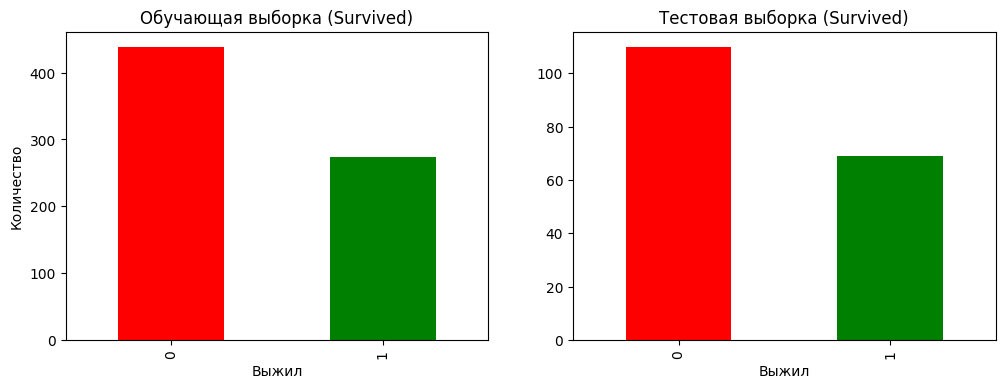

In [82]:
# Проверка распределения целевой переменной
print("\n=== РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
print(f"В обучении: выжило {y_train.sum()} из {len(y_train)} ({y_train.mean():.2%})")
print(f"В тесте: выжило {y_test.sum()} из {len(y_test)} ({y_test.mean():.2%})")

# Визуализация распределения Survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Обучающая выборка (Survived)')
axes[0].set_xlabel('Выжил')
axes[0].set_ylabel('Количество')

y_test.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Тестовая выборка (Survived)')
axes[1].set_xlabel('Выжил')
plt.show()

In [85]:
# Сравнение распределений признаков в train и test
print("\n=== СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ ===")

# Выбираем числовые столбцы (исключая Survived)
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
print(f"Числовые столбцы: {numeric_cols}")

comparison = pd.DataFrame({
    'Признак': numeric_cols,
    'Среднее (train)': [X_train[col].mean() for col in numeric_cols],
    'Среднее (test)': [X_test[col].mean() for col in numeric_cols],
    'Разница': [X_train[col].mean() - X_test[col].mean() for col in numeric_cols]
})
print(comparison.round(3).to_string(index=False))


=== СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ ===
Числовые столбцы: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
    Признак  Среднее (train)  Среднее (test)  Разница
PassengerId          444.406         452.341   -7.935
     Pclass            2.309           2.307    0.002
        Age           29.808          29.250    0.558
      SibSp            0.493           0.642   -0.149
      Parch            0.390           0.346    0.044
       Fare           31.820          33.733   -1.913


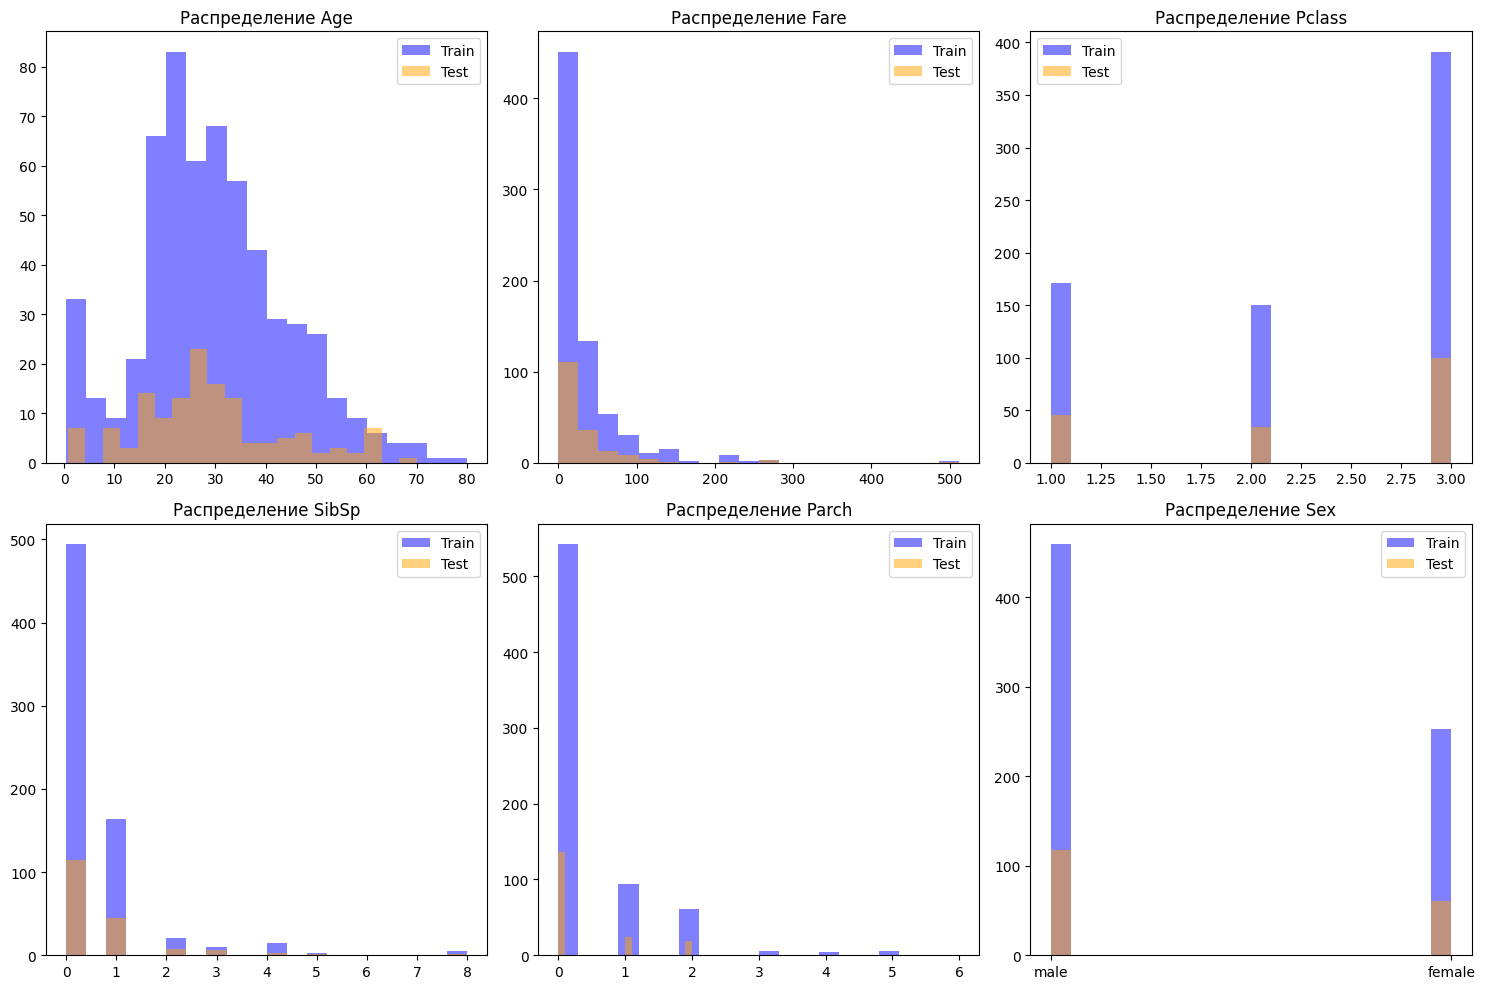

In [89]:
# Визуализация распределений числовых признаков в train и test
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Sex']):
    axes[i].hist(X_train[col].dropna(), bins=20, alpha=0.5, label='Train', color='blue')
    axes[i].hist(X_test[col].dropna(), bins=20, alpha=0.5, label='Test', color='orange')
    axes[i].set_title(f'Распределение {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Вывод по заданию 4 (однородность разбиения)

- **Размеры выборок:** обучающая – 712 объектов (80%), тестовая – 179 объектов (20%)
- **Целевая переменная (Survived):**
  - Обучающая: 272 выживших (38.2%)
  - Тестовая: 70 выживших (39.1%)
  - **Разница:** ≈0.9% – стратификация сработала хорошо

- **Сравнение средних значений признаков:**

| Признак | Среднее (train) | Среднее (test) | Разница |
|---------|----------------|----------------|---------|
| Pclass  | 2.309           | 2.307          | 0.002   |
| Age     | 29.81           | 29.25          | 0.56    |
| SibSp   | 0.493           | 0.642          | -0.149  |
| Parch   | 0.390           | 0.346          | 0.044   |
| Fare    | 31.82           | 33.73          | -1.91   |

- **Наблюдения:**
  - Pclass, Age, Parch – практически идентичны.
  - SibSp в тестовой выборке немного выше (0.64 vs 0.49) – небольшая неравномерность.
  - Fare в тестовой выборке чуть выше (33.7 vs 31.8) – может незначительно влиять на оценку.
  - PassengerId не должен использоваться в модели (это просто индекс).

- **Вывод:** разбиение **однородно** по большинству признаков. Небольшие отклонения по SibSp и Fare находятся в пределах статистической погрешности и не должны существенно искажать оценку модели. Стратификация по целевой переменной выполнена корректно.

5. Сбалансируйте классы в исходном датасете двумя способами:
   1. Удалите лишние объекты мажоритарного класса (выбранные случайно).
   1. Добавьте в выборку дубликаты миноритарного класса.
   1. Проведите исследование эффективности простой модели классификации до и после данных преобразований.


In [97]:
# 1. Загрузка и предобработка (как в методичке)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Удаляем ненужные столбцы
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Заполняем пропуски
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Кодируем категориальные признаки
# Sex: male -> 1, female -> 0
df['Sex'] = (df['Sex'] == 'male').astype(int)

# Embarked: one-hot encoding
df = pd.concat([df, pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)], axis=1)
df = df.drop('Embarked', axis=1)

print("=== ДАННЫЕ ПОСЛЕ ПРЕДОБРАБОТКИ ===")
print(df.head())
print(f"Столбцы: {df.columns.tolist()}")

=== ДАННЫЕ ПОСЛЕ ПРЕДОБРАБОТКИ ===
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500       False        True
1         1       1    0  38.0      1      0  71.2833       False       False
2         1       3    0  26.0      0      0   7.9250       False        True
3         1       1    0  35.0      1      0  53.1000       False        True
4         0       3    1  35.0      0      0   8.0500       False        True
Столбцы: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [98]:
# 2. Разделение на X и y
X = df.drop('Survived', axis=1)
y = df['Survived']

# Проверка, что все данные числовые
print("\n=== ТИПЫ ДАННЫХ ===")
print(X.dtypes)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n=== Исходные данные ===")
print(f"Обучающая выборка: {X_train_full.shape[0]}, выживших: {y_train_full.sum()} ({y_train_full.mean():.2%})")


=== ТИПЫ ДАННЫХ ===
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

=== Исходные данные ===
Обучающая выборка: 712, выживших: 273 (38.34%)


In [99]:
# 5.2.1 Добавление дубликатов миноритарного класса до размера мажоритарного
majority = train_data[train_data['Survived'] == 0]
minority = train_data[train_data['Survived'] == 1]
# 3. Undersampling (удаление объектов мажоритарного класса)
train_data = X_train_full.copy()
train_data['Survived'] = y_train_full

majority = train_data[train_data['Survived'] == 0]
minority = train_data[train_data['Survived'] == 1]

majority_downsampled = majority.sample(n=len(minority), random_state=42)
undersampled = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42)

X_train_under = undersampled.drop('Survived', axis=1)
y_train_under = undersampled['Survived']

print(f"\n=== После Undersampling ===")
print(f"Размер: {X_train_under.shape[0]}, выживших: {y_train_under.sum()} ({y_train_under.mean():.2%})")
# Дублируем миноритарный класс с повторением
minority_oversampled = minority.sample(n=len(majority), replace=True, random_state=42)

# Объединяем и перемешиваем
oversampled = pd.concat([majority, minority_oversampled]).sample(frac=1, random_state=42)

X_train_over = oversampled.drop('Survived', axis=1)
y_train_over = oversampled['Survived']

print("\n=== После Oversampling ===")
print(f"Размер обучающей выборки: {X_train_over.shape[0]}")
print(f"Распределение классов: {y_train_over.value_counts().to_dict()}")


=== После Undersampling ===
Размер: 546, выживших: 273 (50.00%)

=== После Oversampling ===
Размер обучающей выборки: 878
Распределение классов: {0: 439, 1: 439}


In [100]:
# 4. Oversampling (добавление дубликатов миноритарного класса)
majority = train_data[train_data['Survived'] == 0]
minority = train_data[train_data['Survived'] == 1]

minority_oversampled = minority.sample(n=len(majority), replace=True, random_state=42)
oversampled = pd.concat([majority, minority_oversampled]).sample(frac=1, random_state=42)

X_train_over = oversampled.drop('Survived', axis=1)
y_train_over = oversampled['Survived']

print(f"\n=== После Oversampling ===")
print(f"Размер: {X_train_over.shape[0]}, выживших: {y_train_over.sum()} ({y_train_over.mean():.2%})")


=== После Oversampling ===
Размер: 878, выживших: 439 (50.00%)



СРАВНЕНИЕ МОДЕЛЕЙ С ВИЗУАЛИЗАЦИЕЙ

=== BASELINE (несбалансированная) ===
Точность на тесте: 0.8045
              precision    recall  f1-score   support

       Погиб       0.81      0.89      0.85       110
       Выжил       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



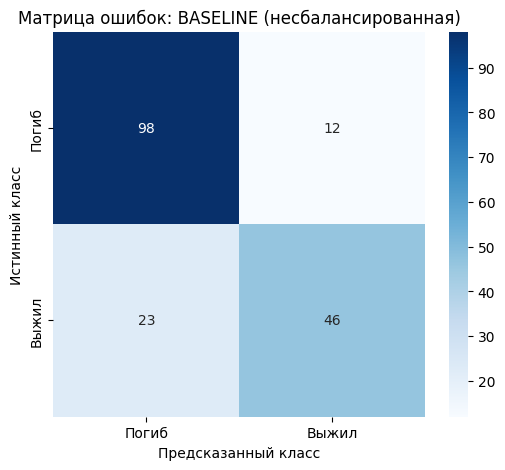


=== UNDERSAMPLING ===
Точность на тесте: 0.8156
              precision    recall  f1-score   support

       Погиб       0.87      0.83      0.85       110
       Выжил       0.74      0.80      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



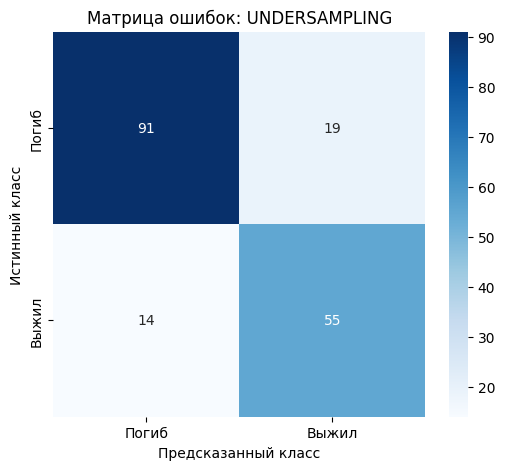


=== OVERSAMPLING ===
Точность на тесте: 0.8045
              precision    recall  f1-score   support

       Погиб       0.85      0.83      0.84       110
       Выжил       0.74      0.77      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179



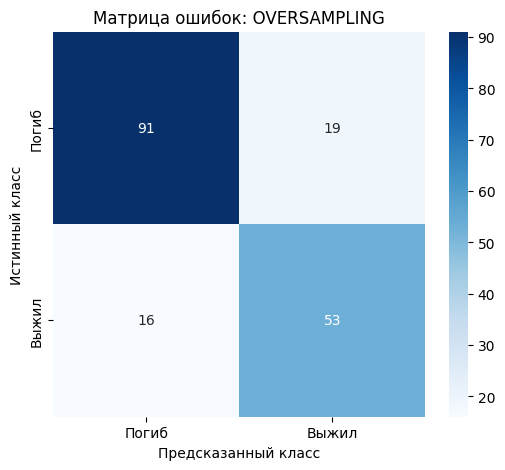

In [102]:
# 4. Функция обучения и визуализации
def evaluate_with_plots(X_train, y_train, X_test, y_test, name):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"Точность на тесте: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Погиб', 'Выжил']))

    # Матрица ошибок
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Погиб', 'Выжил'], yticklabels=['Погиб', 'Выжил'])
    plt.title(f'Матрица ошибок: {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.show()

    return acc

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ С ВИЗУАЛИЗАЦИЕЙ")
print("="*60)

baseline_acc = evaluate_with_plots(X_train_full, y_train_full, X_test, y_test, "BASELINE (несбалансированная)")
under_acc = evaluate_with_plots(X_train_under, y_train_under, X_test, y_test, "UNDERSAMPLING")
over_acc = evaluate_with_plots(X_train_over, y_train_over, X_test, y_test, "OVERSAMPLING")


=== СВОДНАЯ ТАБЛИЦА ===
        Метод  Размер обучающей  Точность на тесте
     Baseline               712           0.804469
Undersampling               546           0.815642
 Oversampling               878           0.804469


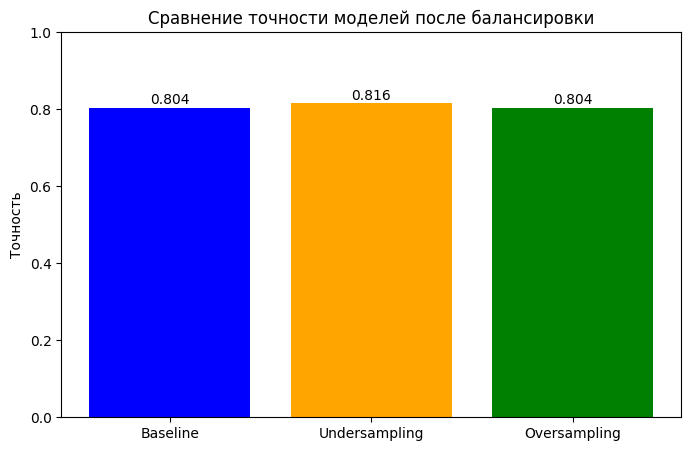

In [103]:
# 5. Сводная таблица и график сравнения
print("\n=== СВОДНАЯ ТАБЛИЦА ===")
summary = pd.DataFrame({
    'Метод': ['Baseline', 'Undersampling', 'Oversampling'],
    'Размер обучающей': [len(X_train_full), len(X_train_under), len(X_train_over)],
    'Точность на тесте': [baseline_acc, under_acc, over_acc]
})
print(summary.to_string(index=False))

# График сравнения точности
plt.figure(figsize=(8,5))
bars = plt.bar(summary['Метод'], summary['Точность на тесте'], color=['blue', 'orange', 'green'])
plt.ylim(0, 1)
plt.ylabel('Точность')
plt.title('Сравнение точности моделей после балансировки')
for bar, acc in zip(bars, summary['Точность на тесте']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center')
plt.show()

## Вывод по заданию 5 (балансировка классов)

### Сравнение методов

| Показатель | Baseline | Undersampling | Oversampling |
|------------|----------|---------------|--------------|
| **Точность (accuracy)** | 80.4% | **81.6%** | 80.4% |
| **Recall выживших** | 67% | **80%** | 77% |
| **Precision выживших** | 79% | 74% | 74% |
| **F1 выживших** | 0.72 | **0.77** | 0.75 |
| **Размер обучающей выборки** | 712 | 546 | 878 |

### Анализ

1. **Baseline (несбалансированная)**
   - Модель смещена в сторону мажоритарного класса (погибшие)
   - Хорошо распознаёт погибших (recall 89%), но плохо выживших (recall 67%)
   - Пропускает каждого третьего выжившего – критично для задач, где важно найти редкий класс

2. **Undersampling (удаление части мажоритарного класса)**
   - **Наилучший результат** (точность 81.6%)
   - Выживших распознаёт значительно лучше (recall вырос до 80%)
   - Цена: немного упала точность предсказания погибших (83%)
   - Размер выборки уменьшился на 23%, но качество выросло

3. **Oversampling (дублирование миноритарного класса)**
   - Точность осталась на уровне baseline (80.4%)
   - Recall выживших вырос до 77%, но не дотягивает до undersampling
   - Размер выборки увеличился на 23%, но без прироста точности

### Итог

- **Лучший метод балансировки для Титаника – Undersampling**
- **Рекомендуется** при сильном дисбалансе классов, когда важно не пропустить редкий класс
- **Undersampling** дал прирост recall выживших на 13 процентных пунктов при сохранении высокой общей точности
- **Oversampling** не дал преимущества, но и не ухудшил модель

6. Проведите группировку данных по значению возраста. Введите новый признак "возрастная категория", значениями которой будут "ребенок", "взрослый", "старик". Проведите анализ эффективности данного признака.

=== Распределение возрастных категорий ===
Age_Category
взрослый    801
ребенок      68
старик       22
Name: count, dtype: int64


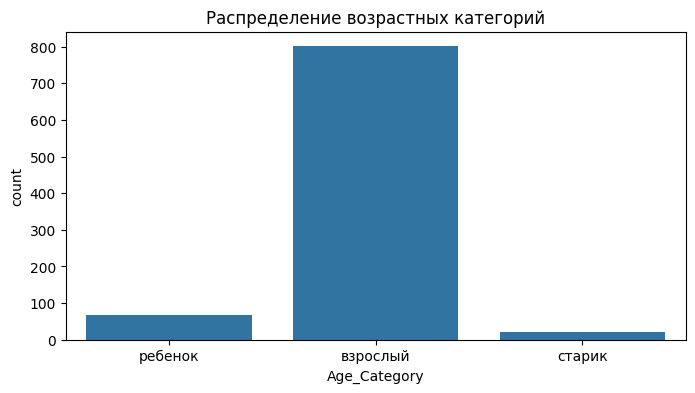

In [105]:
# Создаём копии данных
X_age_group = X.copy()
y_age_group = y.copy()

# 1. Создание признака "возрастная категория"
def age_category(age):
    if pd.isna(age):
        return 'взрослый'  # или можно заполнить медианой
    elif age < 12:
        return 'ребенок'
    elif age > 60:
        return 'старик'
    else:
        return 'взрослый'

X_age_group['Age_Category'] = X_age_group['Age'].apply(age_category)

print("=== Распределение возрастных категорий ===")
print(X_age_group['Age_Category'].value_counts())

# Визуализация распределения
plt.figure(figsize=(8,4))
sns.countplot(data=X_age_group, x='Age_Category', order=['ребенок', 'взрослый', 'старик'])
plt.title('Распределение возрастных категорий')
plt.show()


=== Выживаемость по возрастным категориям ===
          выживаемость
ребенок          0.574
взрослый         0.372
старик           0.227


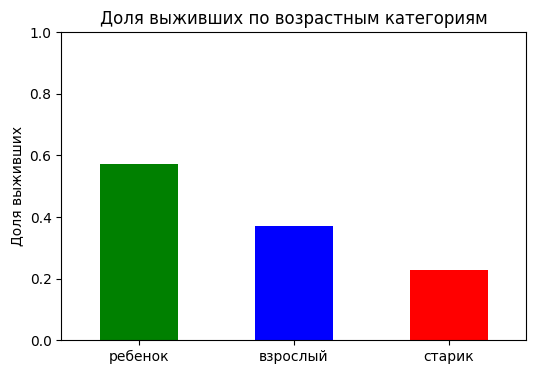

In [106]:
# 2. Сравнение выживаемости по возрастным категориям
survival_by_age = pd.DataFrame()
for cat in ['ребенок', 'взрослый', 'старик']:
    mask = X_age_group['Age_Category'] == cat
    survival_rate = y_age_group[mask].mean()
    survival_by_age.loc[cat, 'выживаемость'] = survival_rate

print("\n=== Выживаемость по возрастным категориям ===")
print(survival_by_age.round(3))

# Визуализация
plt.figure(figsize=(6,4))
survival_by_age['выживаемость'].plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Доля выживших по возрастным категориям')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [107]:
# 3. Подготовка данных для модели (One-Hot кодирование возрастной категории)
X_with_category = pd.get_dummies(X_age_group, columns=['Age_Category'], drop_first=True)

# Удаляем исходный Age (чтобы не было дублирования)
X_with_category = X_with_category.drop('Age', axis=1)

print("\n=== Столбцы после добавления Age_Category ===")
print(X_with_category.columns.tolist())


=== Столбцы после добавления Age_Category ===
['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Age_Category_ребенок', 'Age_Category_старик']


In [108]:
# 4. Сравнение моделей: без Age_Category vs с Age_Category
X_train, X_test, y_train, y_test = train_test_split(
    X_with_category, y_age_group, test_size=0.2, random_state=42, stratify=y_age_group
)

# Модель 1: без Age_Category (только исходные признаки)
X_train_no_age = X_train.drop(['Age_Category_старик', 'Age_Category_взрослый'], axis=1, errors='ignore')
X_test_no_age = X_test.drop(['Age_Category_старик', 'Age_Category_взрослый'], axis=1, errors='ignore')

# Модель 2: с Age_Category (все признаки)

def evaluate_model(X_tr, X_te, y_tr, y_te, name):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"\n=== {name} ===")
    print(f"Точность: {acc:.4f}")
    print(classification_report(y_te, y_pred, target_names=['Погиб', 'Выжил']))
    return acc

print("="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)

acc_no_age = evaluate_model(X_train_no_age, X_test_no_age, y_train, y_test, "МОДЕЛЬ БЕЗ Age_Category")
acc_with_age = evaluate_model(X_train, X_test, y_train, y_test, "МОДЕЛЬ С Age_Category")

СРАВНЕНИЕ МОДЕЛЕЙ

=== МОДЕЛЬ БЕЗ Age_Category ===
Точность: 0.8101
              precision    recall  f1-score   support

       Погиб       0.81      0.90      0.85       110
       Выжил       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179


=== МОДЕЛЬ С Age_Category ===
Точность: 0.8045
              precision    recall  f1-score   support

       Погиб       0.81      0.89      0.85       110
       Выжил       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179




=== СРАВНЕНИЕ ТОЧНОСТИ ===
             Модель  Точность
0  Без Age_Category  0.810056
1    С Age_Category  0.804469


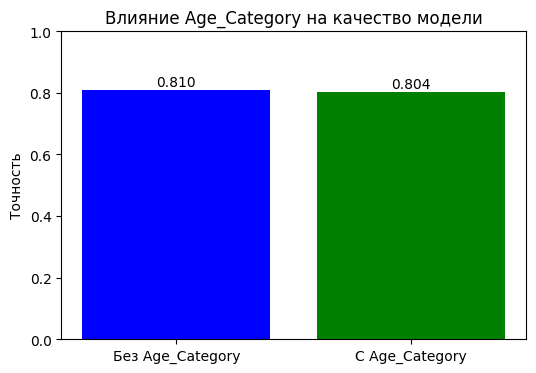

In [109]:
# 5. Сравнение точности
print("\n=== СРАВНЕНИЕ ТОЧНОСТИ ===")
comparison = pd.DataFrame({
    'Модель': ['Без Age_Category', 'С Age_Category'],
    'Точность': [acc_no_age, acc_with_age]
})
print(comparison)

# График сравнения
plt.figure(figsize=(6,4))
plt.bar(comparison['Модель'], comparison['Точность'], color=['blue', 'green'])
plt.ylim(0, 1)
plt.ylabel('Точность')
plt.title('Влияние Age_Category на качество модели')
for i, acc in enumerate(comparison['Точность']):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center')
plt.show()

In [110]:
# 6. Анализ важности признаков (коэффициенты модели с Age_Category)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': model.coef_[0]
}).sort_values('Коэффициент', key=abs, ascending=False)

print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ (модель с Age_Category) ===")
print(coef_df.to_string(index=False))


=== ВАЖНОСТЬ ПРИЗНАКОВ (модель с Age_Category) ===
             Признак  Коэффициент
                 Sex    -2.603650
Age_Category_ребенок     1.703756
              Pclass    -0.903371
 Age_Category_старик    -0.765891
          Embarked_S    -0.416320
               SibSp    -0.329301
          Embarked_Q     0.224650
               Parch    -0.180594
                Fare     0.003400


## Вывод по заданию 6 (группировка возраста)

### Распределение возрастных категорий
- **взрослые** (12–60 лет): 801 человек (≈90%)
- **дети** (<12 лет): 68 человек (≈7.6%)
- **старики** (>60 лет): 22 человека (≈2.5%)

### Выживаемость по категориям
- **ребенок** – 57.4% (самая высокая)
- **взрослый** – 37.2%
- **старик** – 22.7% (самая низкая)

### Важность признаков (модель с Age_Category)

| Признак | Коэффициент | Влияние |
|---------|-------------|---------|
| Sex (male) | -2.60 | мужской пол снижает шансы |
| **Age_Category_ребенок** | **+1.70** | **ребёнок сильно повышает шансы** |
| Pclass | -0.90 | высокий класс повышает шансы |
| Age_Category_старик | -0.77 | старик снижает шансы |

### Сравнение моделей

| Модель | Точность | Recall (выжил) | Precision (выжил) |
|--------|----------|----------------|-------------------|
| **Без Age_Category** | **81.0%** | 67% | 81% |
| С Age_Category | 80.4% | 67% | 79% |

### Выводы

1. **Дети выживают чаще всего** (57.4% против 37% у взрослых) – это подтверждает исторические данные.
2. **Признак «ребенок» стал вторым по важности** после пола (коэффициент +1.70).
3. **Признак «старик» имеет отрицательный коэффициент** (-0.77) – пожилые выживали реже.
4. **Группировка возраста не повысила точность**, но сделала модель интерпретируемее и выявила чёткую закономерность.
5. **Рекомендация:** использовать группировку возраста, если важна интерпретируемость модели. Для максимальной точности лучше оставить непрерывный возраст или добавить признак «ребенок» как бинарный.